In [1]:
if (!require("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

BiocManager::install(c("DESeq2", "airway"))

Bioconductor version '3.22' is out-of-date; the current release version '3.23'
  is available with R version '4.6'; see https://bioconductor.org/install

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cloud.r-project.org

Bioconductor version 3.22 (BiocManager 1.30.27), R 4.5.2 (2025-10-31)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'DESeq2' 'airway'”
Installation paths not writeable, unable to update packages
  path: /usr/lib/R/library
  packages:
    class, cluster, KernSmooth, lattice, MASS, Matrix, nlme, nnet, rpart,
    spatial, survival



In [1]:
library(DESeq2)
library(airway)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The follo

In [2]:
data(airway)
airway

class: RangedSummarizedExperiment 
dim: 63677 8 
metadata(1): ''
assays(1): counts
rownames(63677): ENSG00000000003 ENSG00000000005 ... ENSG00000273492
  ENSG00000273493
rowData names(10): gene_id gene_name ... seq_coord_system symbol
colnames(8): SRR1039508 SRR1039509 ... SRR1039520 SRR1039521
colData names(9): SampleName cell ... Sample BioSample

# Check the raw counts

In [3]:
head(assay(airway))

,SRR1039508,SRR1039509,SRR1039512,SRR1039513,SRR1039516,SRR1039517,SRR1039520,SRR1039521
ENSG00000000003,679,448,873,408,1138,1047,770,572
ENSG00000000005,0,0,0,0,0,0,0,0
ENSG00000000419,467,515,621,365,587,799,417,508
ENSG00000000457,260,211,263,164,245,331,233,229
ENSG00000000460,60,55,40,35,78,63,76,60
ENSG00000000938,0,0,2,0,1,0,0,0


# Sample metadata to check which sample belongs to which condition

In [4]:
colData(airway)

DataFrame with 8 rows and 9 columns
           SampleName     cell      dex    albut        Run avgLength
             <factor> <factor> <factor> <factor>   <factor> <integer>
SRR1039508 GSM1275862  N61311     untrt    untrt SRR1039508       126
SRR1039509 GSM1275863  N61311     trt      untrt SRR1039509       126
SRR1039512 GSM1275866  N052611    untrt    untrt SRR1039512       126
SRR1039513 GSM1275867  N052611    trt      untrt SRR1039513        87
SRR1039516 GSM1275870  N080611    untrt    untrt SRR1039516       120
SRR1039517 GSM1275871  N080611    trt      untrt SRR1039517       126
SRR1039520 GSM1275874  N061011    untrt    untrt SRR1039520       101
SRR1039521 GSM1275875  N061011    trt      untrt SRR1039521        98
           Experiment    Sample    BioSample
             <factor>  <factor>     <factor>
SRR1039508  SRX384345 SRS508568 SAMN02422669
SRR1039509  SRX384346 SRS508567 SAMN02422675
SRR1039512  SRX384349 SRS508571 SAMN02422678
SRR1039513  SRX384350 SRS508572 SAMN024

# Compare samples based on "dex" column

In [5]:
dds <- DESeqDataSet(airway, design = ~ dex)
dds

class: DESeqDataSet 
dim: 63677 8 
metadata(2): '' version
assays(1): counts
rownames(63677): ENSG00000000003 ENSG00000000005 ... ENSG00000273492
  ENSG00000273493
rowData names(10): gene_id gene_name ... seq_coord_system symbol
colnames(8): SRR1039508 SRR1039509 ... SRR1039520 SRR1039521
colData names(9): SampleName cell ... Sample BioSample

# Filter out low-count genes

In [6]:
keep <- rowSums(counts(dds)) >= 10
dds <- dds[keep, ]

In [7]:
nrow(dds)

[1] 22369

# Run the full DESeq2 pipeline

In [8]:
dds <- DESeq(dds)

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



# Extract results

In [9]:
res <- results(dds)
head(res)

log2 fold change (MLE): dex untrt vs trt 
Wald test p-value: dex untrt vs trt 
DataFrame with 6 rows and 6 columns
                 baseMean log2FoldChange     lfcSE      stat    pvalue
                <numeric>      <numeric> <numeric> <numeric> <numeric>
ENSG00000000003  708.5979      0.3788232  0.173155  2.187770 0.0286863
ENSG00000000419  520.2963     -0.2037892  0.100742 -2.022877 0.0430858
ENSG00000000457  237.1621     -0.0340629  0.126476 -0.269324 0.7876803
ENSG00000000460   57.9324      0.1171569  0.301583  0.388474 0.6976656
ENSG00000000971 5817.3108     -0.4409785  0.258776 -1.704096 0.0883632
ENSG00000001036 1282.1007      0.2419098  0.119713  2.020752 0.0433054
                     padj
                <numeric>
ENSG00000000003  0.138469
ENSG00000000419  0.182997
ENSG00000000457  0.929806
ENSG00000000460  0.894232
ENSG00000000971  0.297044
ENSG00000001036  0.183497

# Filter to significant genes

In [10]:
res_sig <- res[which(res$padj < 0.05), ]
head(res_sig)

log2 fold change (MLE): dex untrt vs trt 
Wald test p-value: dex untrt vs trt 
DataFrame with 6 rows and 6 columns
                 baseMean log2FoldChange     lfcSE      stat      pvalue
                <numeric>      <numeric> <numeric> <numeric>   <numeric>
ENSG00000002834 7168.8017      -0.398604 0.1024114  -3.89219 9.93446e-05
ENSG00000003096  377.9753       0.920169 0.1870428   4.91956 8.67385e-07
ENSG00000003402 2546.6093      -1.183447 0.1635391  -7.23648 4.60488e-13
ENSG00000003987   25.5043      -0.988115 0.3272037  -3.01988 2.52878e-03
ENSG00000004059 1225.3505      -0.369229 0.1041902  -3.54379 3.94413e-04
ENSG00000004487 1237.7940       0.298878 0.0830253   3.59984 3.18412e-04
                       padj
                  <numeric>
ENSG00000002834 1.52587e-03
ENSG00000003096 2.42749e-05
ENSG00000003402 5.47090e-11
ENSG00000003987 2.21539e-02
ENSG00000004059 4.92414e-03
ENSG00000004487 4.09180e-03

# Total number of significant genes found

In [11]:
nrow(res_sig)

[1] 2694

In [12]:
res_ordered <- res[order(res$padj), ]
top_genes <- head(res_ordered, 30)

In [13]:
top_gene_names = rownames(top_genes)

In [14]:
heatmap_data <- counts(dds, normalized = TRUE)[top_gene_names, ]

In [15]:
install.packages("pheatmap")

Installing package into ‘/home/shipra_123/R/x86_64-pc-linux-gnu-library/4.5’
(as ‘lib’ is unspecified)



In [15]:
library(pheatmap)

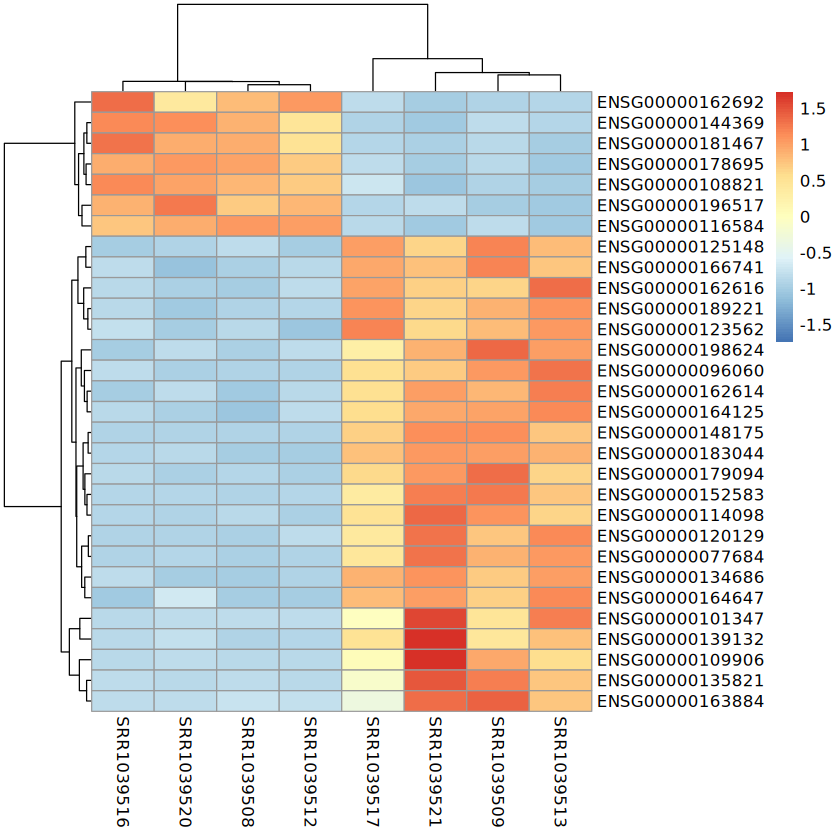

In [17]:
pheatmap(heatmap_data, scale = "row")

In [18]:
library(ggplot2)

In [19]:
res_df <- as.data.frame(res)

In [20]:
library(dplyr)


Attaching package: ‘dplyr’


The following object is masked from ‘package:Biobase’:

    combine


The following object is masked from ‘package:matrixStats’:

    count


The following objects are masked from ‘package:GenomicRanges’:

    intersect, setdiff, union


The following object is masked from ‘package:Seqinfo’:

    intersect


The following objects are masked from ‘package:IRanges’:

    collapse, desc, intersect, setdiff, slice, union


The following objects are masked from ‘package:S4Vectors’:

    first, intersect, rename, setdiff, setequal, union


The following objects are masked from ‘package:BiocGenerics’:

    combine, intersect, setdiff, setequal, union


The following object is masked from ‘package:generics’:

    explain


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [21]:
res_df <- res_df %>% mutate(new_res = if_else(padj < 0.05, TRUE, FALSE))

Warning message:
“Removed 3954 rows containing missing values or values outside the scale range (`geom_point()`).”


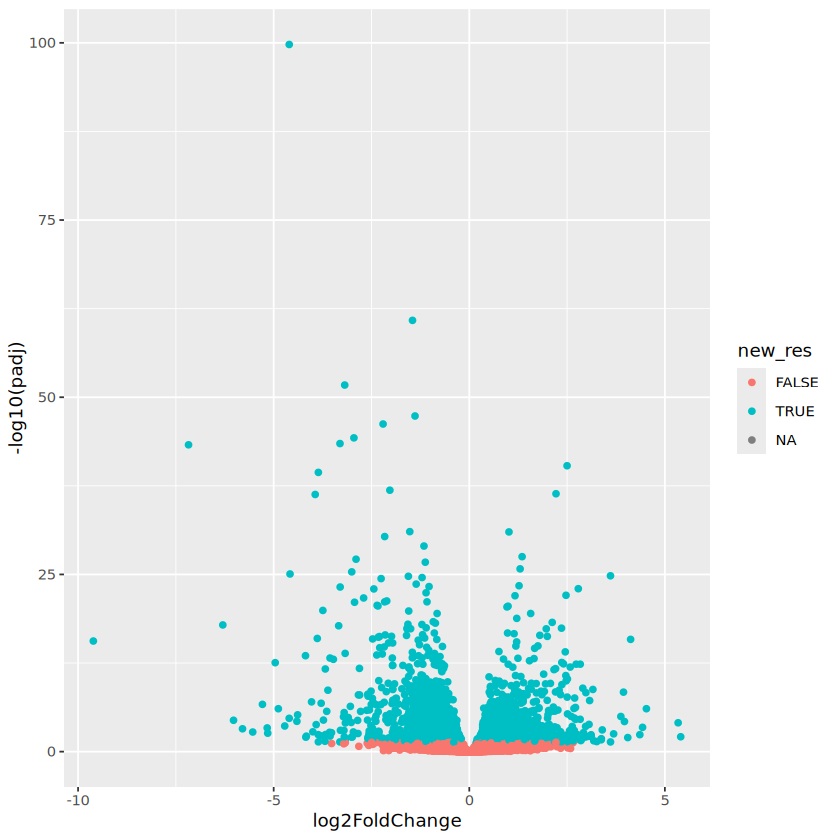

In [22]:
plot <- ggplot(res_df, aes(x = log2FoldChange, y = -log10(padj), color = new_res)) + geom_point()
plot

In [27]:
getwd()

[1] "/home/shipra_123/bioinfo"